# 🌱 AI-Powered Crop Disease Detection

**Goal:** Train a deep learning model (CNN using transfer learning) to classify crop leaf images as healthy or diseased, identifying the specific disease.

**Dataset:** PlantVillage — ~54,000 labeled images across 38 classes (multiple crops, each with healthy + several disease categories).

**Model:** MobileNetV2 pretrained on ImageNet, fine-tuned on plant leaf images (transfer learning — trains fast, works well with limited data, and is small enough to later deploy in a simple web/mobile app).

---

### How to use this notebook
1. In Colab, go to `Runtime > Change runtime type` and select **GPU** (T4 is fine, it's free).
2. Run each cell top to bottom.
3. Read the comments — they explain *why* each step exists, not just what it does. That matters when you explain this project in an interview.


## Step 1: Install & import libraries

In [1]:
# kagglehub lets us pull the dataset directly from Kaggle without manual downloads
!pip install -q kagglehub

import os
# IMPORTANT: this must be set before TensorFlow initializes the GPU.
# cuda_malloc_async avoids TF pre-reserving large "pinned" host memory buffers
# for CPU<->GPU transfer.
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Disable XLA JIT auto-clustering. XLA's convolution-algorithm autotuning can
# request very large "pinned" host scratch buffers while benchmarking conv
# implementations -- on some Colab driver/cuDNN combos, the fallback when that
# fails crashes the kernel instead of degrading gracefully. This was the actual
# cause of the "could not allocate pinned host of size" crash (confirmed: the
# System RAM graph showed plenty of headroom, so it wasn't a RAM problem --
# pinned memory is a separate, much smaller pool from regular RAM).
tf.config.optimizer.set_jit(False)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Download the PlantVillage dataset

We're using the widely-used PlantVillage dataset from Kaggle (via `kagglehub`, no manual login/API key needed for public datasets).

In [2]:
import kagglehub

# Downloads the dataset and returns the local path where it's stored
dataset_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Dataset downloaded to:", dataset_path)

# Look at the folder structure so we know where the actual images live
for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(dirs), "subfolders,", len(files), "files")
    if root.count(os.sep) - dataset_path.count(os.sep) > 1:
        break

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded to: /kaggle/input/plantvillage-dataset
/kaggle/input/plantvillage-dataset -> 1 subfolders, 0 files
/kaggle/input/plantvillage-dataset/plantvillage dataset -> 3 subfolders, 0 files
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented -> 38 subfolders, 0 files


In [3]:
# The dataset usually has a 'color' folder with class-named subfolders (one per crop+disease combo).
# We locate that folder automatically instead of hardcoding a path that might differ.
DATA_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if 'color' in dirs:
        DATA_DIR = os.path.join(root, 'color')
        break

if DATA_DIR is None:
    # Fallback: use the dataset_path directly if structure differs
    DATA_DIR = dataset_path

print("Using data directory:", DATA_DIR)
class_names_preview = sorted(os.listdir(DATA_DIR))
print("Number of classes found:", len(class_names_preview))
print("Example classes:", class_names_preview[:5])

Using data directory: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
Number of classes found: 38
Example classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## Step 3: Load data into train/validation sets

We resize every image to 224x224 (MobileNetV2's expected input size) and split 80% train / 20% validation.

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # reduced from 32 -- lowers per-step memory pressure (host + GPU)
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(class_names)


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spo

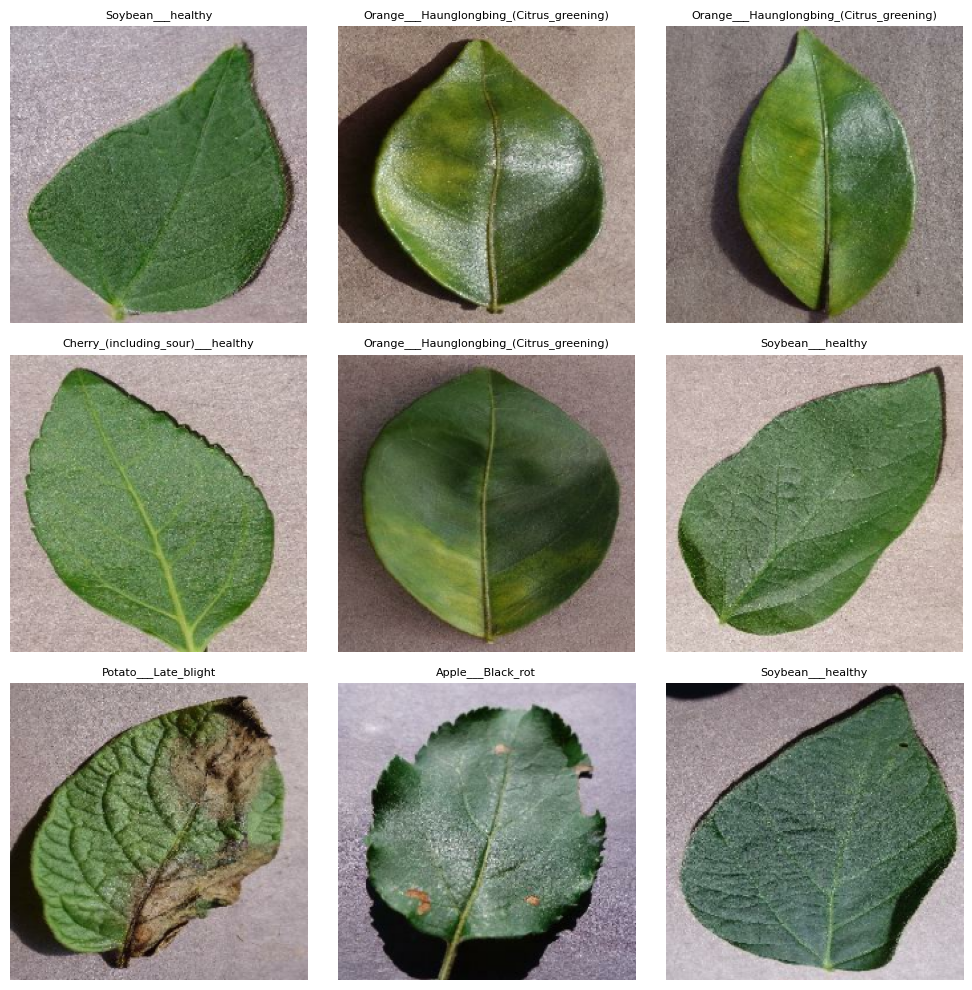

In [5]:
# Quick visual sanity check — look at a few images and their labels
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Performance optimization: cache and prefetch so the GPU isn't waiting on disk I/O
#
# Two crashes so far, two different root causes:
# 1) Disk-caching the full 54k-image train set exhausted system RAM (fixed previously
#    by not caching train_ds).
# 2) Unbounded AUTOTUNE prefetch + a large shuffle buffer caused TF to request an
#    8.5GB "pinned" host memory buffer for GPU transfer, which also failed and crashed
#    the kernel. Fixed here by capping both buffers to small, fixed sizes instead of
#    letting TF grow them automatically.
import glob
for f in glob.glob('/content/train_cache*') + glob.glob('/content/val_cache*'):
    os.remove(f)
    print('Removed old cache file:', f)

# Fixed, small buffer sizes -- no AUTOTUNE here, so TF can't balloon host memory usage.
train_ds = train_ds.shuffle(300).prefetch(buffer_size=2)

# Validation set: safe to cache since it's ~20% the size, still capped prefetch.
val_ds = val_ds.cache('/content/val_cache').prefetch(buffer_size=2)

print("Train batches:", train_ds.cardinality().numpy())
print("Val batches:", val_ds.cardinality().numpy())


Train batches: 2716
Val batches: 679


## Step 4: Build the model (Transfer Learning with MobileNetV2)

Instead of training a CNN from scratch (which needs huge amounts of data and time), we use MobileNetV2 — already trained on millions of ImageNet images — as a fixed feature extractor. We freeze its weights and add our own classifier head on top for the 38 plant disease classes.

This is the standard, practical approach used in real-world image classification projects with limited data/compute.

In [7]:
# Data augmentation: randomly flip/rotate/zoom training images so the model
# generalizes better and doesn't just memorize the training set
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# MobileNetV2 expects pixel values scaled to [-1, 1]
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,   # exclude ImageNet's final classification layer
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained weights for the first training phase

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # reduces overfitting
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 5: Train the model (Phase 1 — frozen base)

In [8]:
EPOCHS_PHASE1 = 8

# Checkpoint after every epoch. If Colab restarts/disconnects mid-training again,
# you won't lose progress — you can reload this file and resume instead of
# starting over from epoch 0.
checkpoint_phase1 = tf.keras.callbacks.ModelCheckpoint(
    '/content/phase1_checkpoint.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

# If a checkpoint from a previous (interrupted) run exists, resume from it
# instead of retraining from scratch.
import os as _os
if _os.path.exists('/content/phase1_checkpoint.keras'):
    print("Found existing checkpoint — resuming from it instead of starting fresh.")
    model = tf.keras.models.load_model('/content/phase1_checkpoint.keras')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop, checkpoint_phase1]
)


Epoch 1/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7641 - loss: 0.8872
Epoch 1: val_accuracy improved from None to 0.92073, saving model to /content/phase1_checkpoint.keras

Epoch 1: finished saving model to /content/phase1_checkpoint.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 260s 87ms/step - accuracy: 0.8554 - loss: 0.5000 - val_accuracy: 0.9207 - val_loss: 0.2485
Epoch 2/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9137 - loss: 0.2714
Epoch 2: val_accuracy improved from 0.92073 to 0.93113, saving model to /content/phase1_checkpoint.keras

Epoch 2: finished saving model to /content/phase1_checkpoint.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 137s 47ms/step - accuracy: 0.9155 - loss: 0.2610 - val_accuracy: 0.9311 - val_loss: 0.2138
Epoch 3/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9198 - loss: 0.2460
Epoch 3: val_accuracy improved from 0.93113 to 0.94559, saving model to /content/phase1_checkpoint.keras

Epoch 3: finished saving model to /content/

## Step 6: Fine-tune (Phase 2 — unfreeze top layers)

Now we unfreeze the last portion of MobileNetV2 and train with a much smaller learning rate. This lets the model adapt its higher-level features specifically to plant leaves, usually giving a meaningful accuracy boost over the frozen-base version.

In [9]:
base_model.trainable = True

# Freeze all layers except the last 30 — fine-tune only the higher-level features
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR to avoid destroying learned features
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_phase2 = tf.keras.callbacks.ModelCheckpoint(
    '/content/phase2_checkpoint.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

EPOCHS_PHASE2 = 6
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=[early_stop, checkpoint_phase2]
)


Epoch 1/6
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7958 - loss: 0.8794
Epoch 1: val_accuracy improved from None to 0.94908, saving model to /content/phase2_checkpoint.keras

Epoch 1: finished saving model to /content/phase2_checkpoint.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 174s 57ms/step - accuracy: 0.8659 - loss: 0.4821 - val_accuracy: 0.9491 - val_loss: 0.1641
Epoch 2/6
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9217 - loss: 0.2404
Epoch 2: val_accuracy improved from 0.94908 to 0.96032, saving model to /content/phase2_checkpoint.keras

Epoch 2: finished saving model to /content/phase2_checkpoint.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 165s 57ms/step - accuracy: 0.9265 - loss: 0.2262 - val_accuracy: 0.9603 - val_loss: 0.1288
Epoch 3/6
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9353 - loss: 0.1902
Epoch 3: val_accuracy improved from 0.96032 to 0.96262, saving model to /content/phase2_checkpoint.keras

Epoch 3: finished saving model to /content/

## Step 7: Plot training curves

This chart is worth including in your project write-up/README — it visually shows the model learning and helps you spot overfitting (val accuracy plateauing/dropping while train accuracy keeps rising).

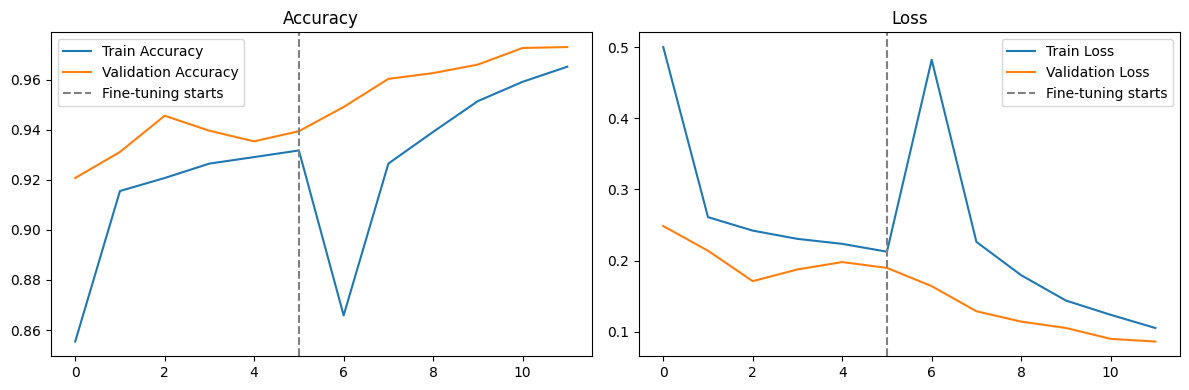

In [10]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(len(history.history['accuracy']) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(len(history.history['loss']) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

## Step 8: Evaluate the model properly

Accuracy alone can be misleading, especially if some classes have fewer images. A classification report (precision/recall/F1 per class) and confusion matrix give a much more honest picture — and these are the numbers you'll want in your resume/README, not just a single accuracy figure.

In [11]:
# Gather true labels and predictions across the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.96      0.95       126
                                 Apple___Black_rot       1.00      0.98      0.99       132
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        55
                                   Apple___healthy       0.98      1.00      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.98       232
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.87      0.87       108
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       219
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.93      0.

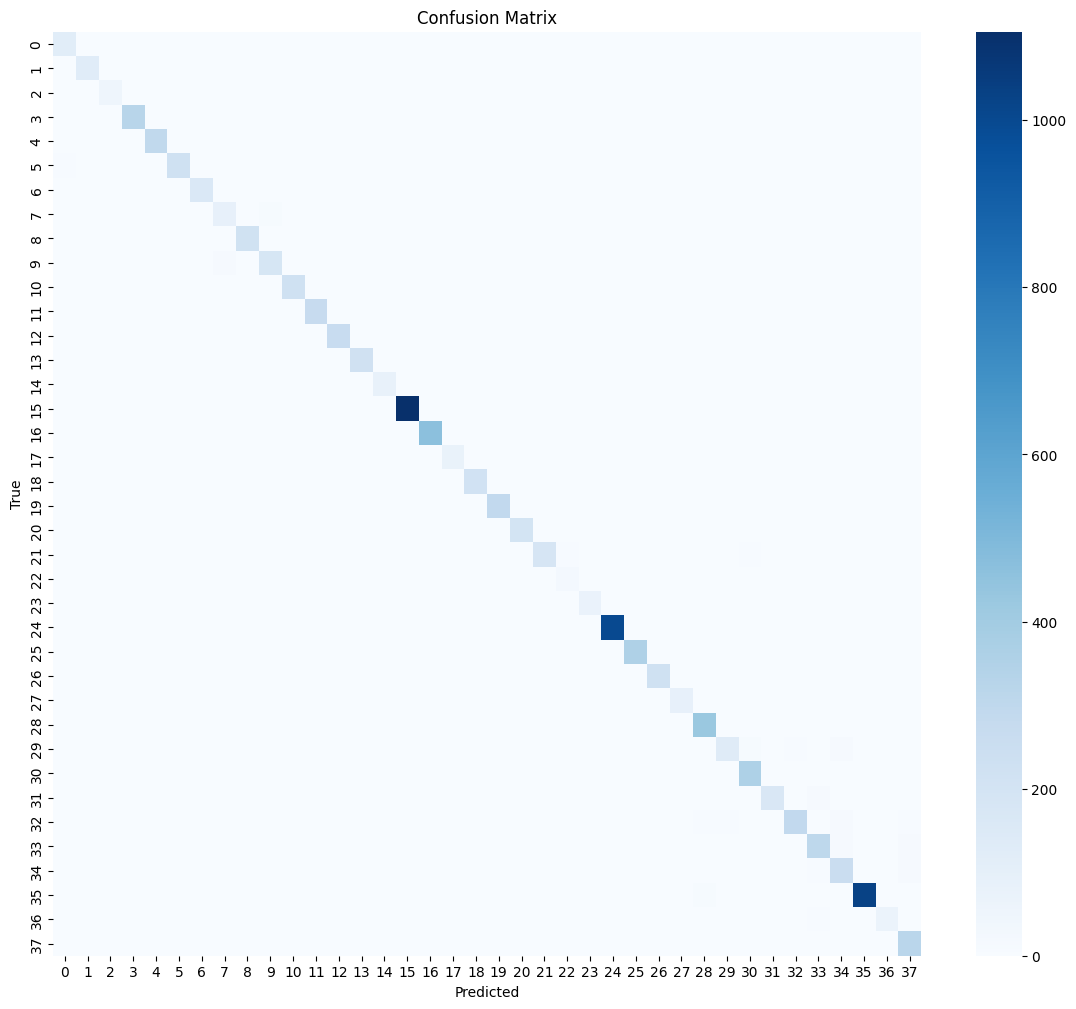

In [12]:
# Confusion matrix — with 38 classes this is large, so we plot it without cell annotations
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Step 9: Save the trained model

We save in the modern Keras format so it can be reloaded later — for the demo app, for a portfolio, or on GitHub (though for GitHub you'd typically link to a download rather than commit the file directly, since model files can be large).

In [13]:
model.save('crop_disease_model.keras')

# Also save the class names — you'll need this list at inference time to turn
# a predicted index back into a human-readable disease name
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Model and class names saved.")

Model and class names saved.


## Step 10: Try it out — predict on a single uploaded image

This is the fun part: upload any leaf photo and see what the model predicts. This same function is what you'd wrap in a Streamlit app for the demo in Phase 2 of the project.

In [14]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, model, class_names, img_size=(224, 224)):
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    predictions = model.predict(img_array, verbose=0)[0]
    top_idx = np.argmax(predictions)
    confidence = predictions[top_idx] * 100

    print(f"Prediction: {class_names[top_idx]}")
    print(f"Confidence: {confidence:.2f}%")

    plt.imshow(img)
    plt.title(f"{class_names[top_idx]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    return class_names[top_idx], confidence

# Uncomment to upload your own test image in Colab:
# uploaded = files.upload()
# test_img_path = list(uploaded.keys())[0]
# predict_disease(test_img_path, model, class_names)

---
## Next Steps (Phase 2 & 3 of the project)

1. **Build a demo app:** Wrap `predict_disease()` in a simple Streamlit app (`st.file_uploader` + this function) so anyone can try it in a browser. This is what makes the project demoable in an interview, not just a notebook.
2. **Add treatment recommendations:** A simple Python dictionary mapping each class name to a short description + treatment tip is enough — no NLP needed to start.
3. **Write a README** with: problem statement, dataset, approach, final accuracy/F1 numbers, screenshots of the confusion matrix and the demo app, and a link to a short screen-recording if possible.
4. **Push to GitHub** with a clear folder structure: `/notebook`, `/app`, `/README.md`. This is the link you'll put on your resume.
